<div>
    <img src="./images/sunpy_logo.png" width="500" align="left"/>
    <br clear="left"/> <!-- This line ensures that the text appears below the image -->
</div>

# Example notebook and exercises!

Now using all the information we have learned, lets analyse the flare event that occured on 2022-04-02 13:00 that was observed by Solar Orbiter and Earth.

As part of this notebook, I'll show some example workflow analysis you could do - but as an exercise, I suggest that you go through our documentation on [sunpy.org](https://sunpy.org/) and our [affiliated packages](https://sunpy.org/affiliated/) (e.g. [sunkit-image](https://docs.sunpy.org/projects/sunkit-image/en/latest/), [sunkit-instrument](https://docs.sunpy.org/projects/sunkit-instruments/en/stable/), and through the [example gallery](https://docs.sunpy.org/en/stable/generated/gallery/index.html) to see what more fun analysis you could do!

In [1]:
import sys
if "google.colab" in sys.modules:
    !wget -q https://raw.githubusercontent.com/hayesla/ESPD_2026/main/requirements.txt
    %pip install --quiet -r requirements.txt
    print("Colab install complete. If imports below fail, do Runtime > Restart runtime.")

In [1]:
import astropy.units as u
from astropy.coordinates import SkyCoord

from sunpy.net import Fido, attrs as a
from sunpy.time import parse_time
import sunpy.map
import sunpy.timeseries as ts
from sunpy.coordinates import frames, get_horizons_coord
from astropy.visualization import ImageNormalize
import sunpy_soar
from aiapy.calibrate import register, update_pointing
import os

import numpy as np
import glob
import matplotlib.pyplot as plt
from sunpy.physics.differential_rotation import solar_rotate_coordinate
from matplotlib import colors

Lets first create a search and download data of interest, for this, lets build a Fido query like before.

Lets first search for GOES XRS data

In [3]:
xrs_res = Fido.search(a.Time("2022-04-02 12:50", "2022-04-02 15:00"), 
                      a.Instrument.xrs, a.goes.SatelliteNumber(16), a.Resolution.flx1s)

In [4]:
xrs_res

Start Time,End Time,Instrument,Physobs,Source,Provider,Resolution,SatelliteNumber
Time,Time,str3,str10,str4,str4,str5,int64
2022-04-02 00:00:00.000,2022-04-02 23:59:59.999,XRS,irradiance,GOES,NOAA,flx1s,16


In [5]:
Fido.fetch(xrs_res, path="./data/{file}")

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

['data/sci_xrsf-l2-flx1s_g16_d20220402_v2-2-1.nc']

In [6]:
goes_xrs = ts.TimeSeries('data/sci_xrsf-l2-flx1s_g16_d20220402_v2-2-1.nc')

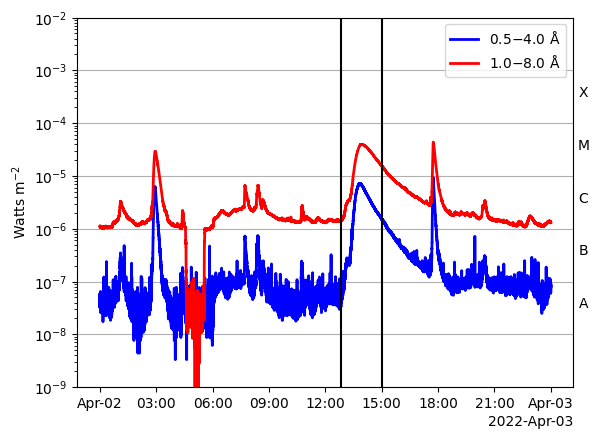

In [7]:
fig, ax = plt.subplots()
goes_xrs.plot()
ax.axvline(parse_time("2022-04-02 12:50").datetime, color='k')
ax.axvline(parse_time("2022-04-02 15:00").datetime, color='k')


Lets now search for AIA 171 Å data and Solar Orbiter EUI/FSI 174 Å data between teh vertical lines in teh GOES/XRS plot over the flare of interest

In [8]:
image_res = Fido.search(a.Time("2022-04-02 12:00", "2022-04-02 14:30"),
                       (a.Instrument.aia & a.Wavelength(171*u.angstrom) & a.Sample(10*u.min)) | 
                       (a.Instrument.eui & a.Level(2) & a.soar.Product("EUI-FSI174-IMAGE")))

In [9]:
Fido.fetch(image_res, path="./data/{file}", site="NSO")

Files Downloaded:   0%|          | 0/30 [00:00<?, ?file/s]

['data/aia.lev1.171A_2022_04_02T12_00_09.35Z.image_lev1.fits', 'data/aia.lev1.171A_2022_04_02T12_10_09.35Z.image_lev1.fits', 'data/aia.lev1.171A_2022_04_02T12_20_09.35Z.image_lev1.fits', 'data/aia.lev1.171A_2022_04_02T12_30_09.35Z.image_lev1.fits', 'data/aia.lev1.171A_2022_04_02T12_40_09.35Z.image_lev1.fits', 'data/aia.lev1.171A_2022_04_02T12_50_09.35Z.image_lev1.fits', 'data/aia.lev1.171A_2022_04_02T13_00_09.35Z.image_lev1.fits', 'data/aia.lev1.171A_2022_04_02T13_10_09.35Z.image_lev1.fits', 'data/aia.lev1.171A_2022_04_02T13_20_09.35Z.image_lev1.fits', 'data/aia.lev1.171A_2022_04_02T13_30_09.35Z.image_lev1.fits', 'data/aia.lev1.171A_2022_04_02T13_40_09.35Z.image_lev1.fits', 'data/aia.lev1.171A_2022_04_02T13_50_09.35Z.image_lev1.fits', 'data/aia.lev1.171A_2022_04_02T14_00_09.35Z.image_lev1.fits', 'data/aia.lev1.171A_2022_04_02T14_10_09.35Z.image_lev1.fits', 'data/aia.lev1.171A_2022_04_02T14_20_09.35Z.image_lev1.fits', 'data/solo_L2_eui-fsi174-image_20220402T120045225_V02.fits', 'data/so

In [10]:
aia_files = glob.glob("./data/*171A*.fits"); aia_files.sort()
eui_files = glob.glob("./data/*fsi174*.fits"); eui_files.sort()

In [11]:
aia_maps = sunpy.map.Map(aia_files)

In [12]:
eui_maps = sunpy.map.Map(eui_files)

(<matplotlib.patches.Polygon at 0x3211b9280>,
 <matplotlib.patches.Polygon at 0x3212f1100>)

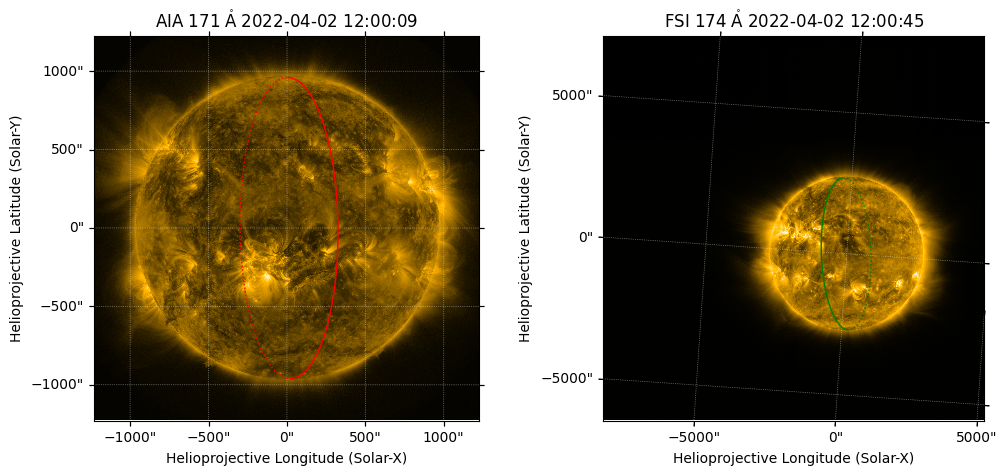

In [13]:
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1, projection=aia_maps[0])
ax2 = fig.add_subplot(1, 2, 2, projection=eui_maps[0])

aia_maps[0].plot(axes=ax1)
eui_maps[0].draw_limb(color='r', axes=ax1)
eui_maps[0].plot(axes=ax2)
aia_maps[0].draw_limb(color='g', axes=ax2)


## Prep AIA data from Level 1 to Level 1.5

To do this we will use sunpy's affiliated package `aiapy`

In [14]:
aia_maps[0].meta["lvl_num"]

1.0

In [15]:
m_updated_pointing = update_pointing(aia_maps[0])
m_registered = register(m_updated_pointing)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

aiapy.aia_pointing_table.csv:   0%|          | 0.00/4.75M [00:00<?, ?B/s]

In [16]:
m_registered.meta["lvl_num"]

1.5

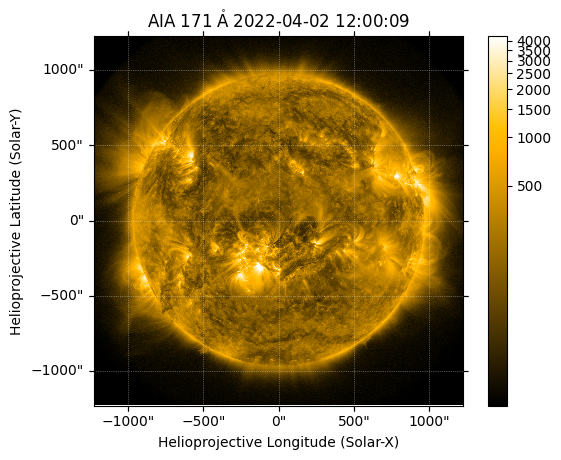

In [17]:
m_registered.plot(clip_interval=[5, 99.98]*u.percent)
plt.colorbar()

## TO DO: Try write a function that takes the input of an AIA map and updates the pointing and registers it to a Level 1.5 map 

Try yourself to do this

## Lets zoom in and rotate EUI maps

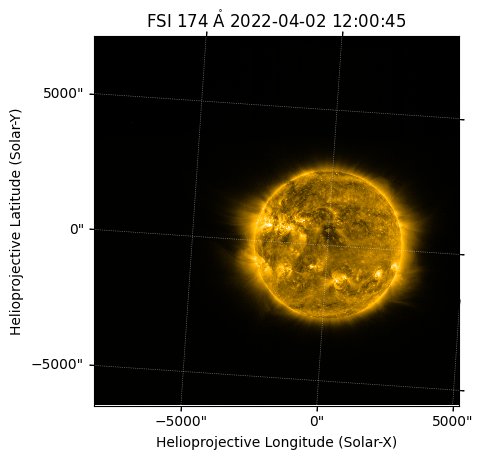

In [18]:
eui_maps[0].plot()

In [19]:
def make_zoom_eui(m):
    bl = SkyCoord(-5000*u.arcsec, -5000*u.arcsec, frame=m.coordinate_frame)
    tr = SkyCoord(5000*u.arcsec, 5000*u.arcsec, frame=m.coordinate_frame)
    return m.submap(bl, top_right=tr).rotate(missing=m.data.min())

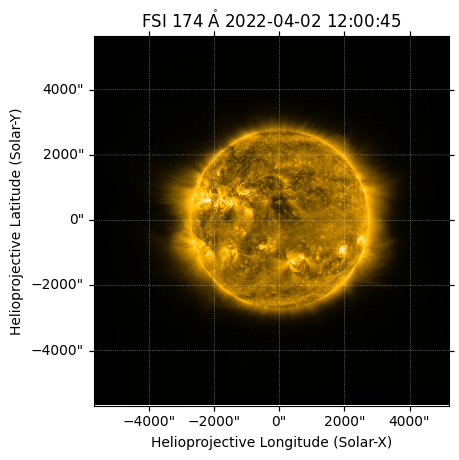

In [20]:
make_zoom_eui(eui_maps[0]).plot()

In [21]:
bl = SkyCoord(700*u.arcsec, 200*u.arcsec, frame=aia_maps[0].coordinate_frame)
tr = SkyCoord(850*u.arcsec, 400*u.arcsec, frame=aia_maps[0].coordinate_frame)


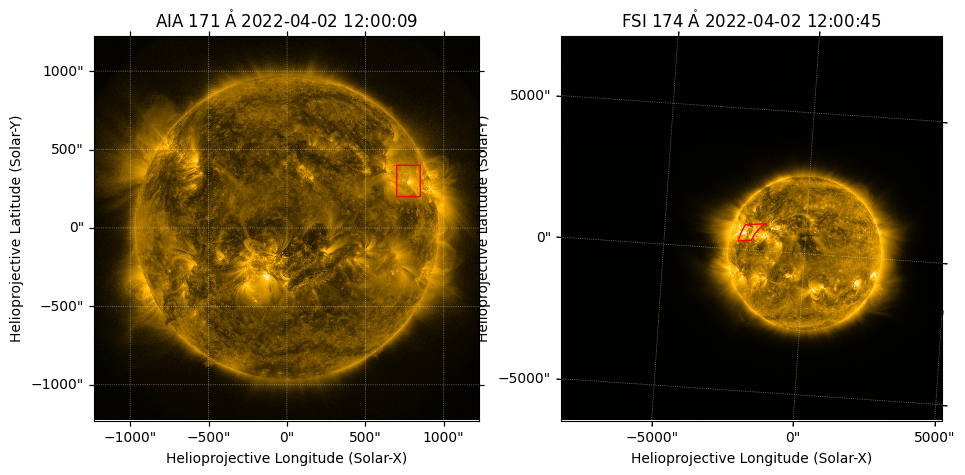

In [22]:
fig = plt.figure(figsize=(11, 5))
ax1 = fig.add_subplot(1, 2, 1, projection=aia_maps[0])
ax2 = fig.add_subplot(1, 2, 2, projection=eui_maps[0])
aia_maps[0].plot(axes=ax1)
aia_maps[0].draw_quadrangle(bl, top_right=tr, axes=ax1, edgecolor='r')

eui_maps[0].plot(axes=ax2)
eui_maps[0].draw_quadrangle(bl, top_right=tr, axes=ax2, edgecolor='r')

## TO DO: crop all the EUI maps to this field of view

## Find HEK areas on the Sun

Lets now show an example of querying the Helio Event Knowledgebase (HEK) to find active regions around the time of thh flare event. Lets first start with finding HMI magnetogram data, and then querying active region data

In [23]:
res = Fido.search(a.Time("2022-04-02 12:00", "2022-04-02 13:00"), 
                  a.Instrument.hmi, a.Physobs.los_magnetic_field)

In [24]:
hmi_file = Fido.fetch(res[0][0], path="./data/{file}")

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

hmi.m_45s.2022.04.02_12_01_30_TAI.magnetogram.fits:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

In [25]:
hmi_map = sunpy.map.Map(hmi_file)

In [26]:
hmi_rotated = hmi_map.rotate(order=3)


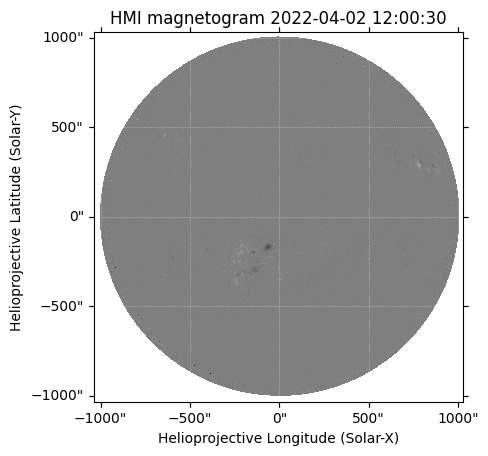

In [27]:
hmi_rotated.plot()

In [28]:
hek_results = Fido.search(a.Time("2022-04-02 12:01", "2022-04-02 14:00"),
                              a.hek.AR, a.hek.FRM.Name=='HMI SHARP')

In [29]:
hek_results["hek"]["event_starttime", "event_endtime"]

event_starttime,event_endtime
Time,Time
2022-04-02 12:00:00.000,2022-04-02 16:00:00.000
2022-04-02 12:00:00.000,2022-04-02 16:00:00.000
2022-04-02 12:00:00.000,2022-04-02 16:00:00.000
2022-04-02 12:00:00.000,2022-04-02 16:00:00.000
2022-04-02 12:00:00.000,2022-04-02 16:00:00.000
2022-04-02 12:00:00.000,2022-04-02 16:00:00.000
2022-04-02 12:00:00.000,2022-04-02 16:00:00.000
2022-04-02 12:00:00.000,2022-04-02 16:00:00.000
2022-04-02 12:00:00.000,2022-04-02 16:00:00.000


In [30]:
responses = hek_results["hek"]
ar_areas = []
for i in range(len(hek_results["hek"])):
    ar = hek_results["hek"][i]
    ar_boundary = ar["hpc_bbox"]
    rotated = solar_rotate_coordinate(ar_boundary, observer=hmi_rotated.observer_coordinate)
    ar_areas.append(rotated)
    

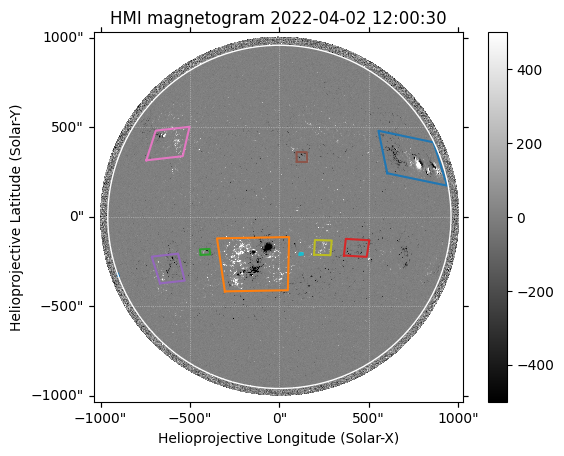

In [31]:
fig = plt.figure()
ax = fig.add_subplot(projection=hmi_rotated)
hmi_rotated.plot(axes=ax, norm=colors.Normalize(vmin=-500, vmax=500))
hmi_rotated.draw_limb()
for ar in ar_areas:
    ax.plot_coord(ar)

plt.colorbar()
plt.show()

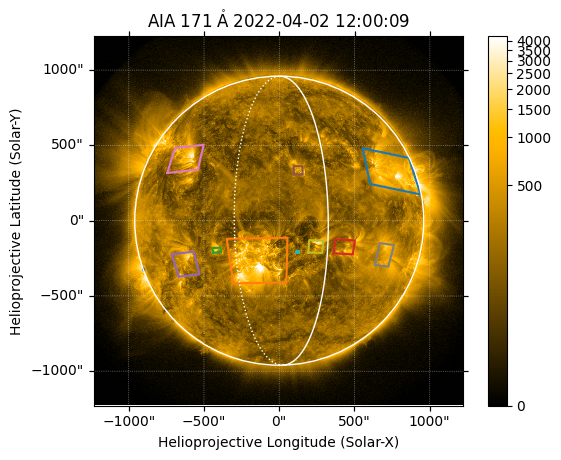

In [32]:
fig = plt.figure()
ax = fig.add_subplot(projection=aia_maps[0])
aia_maps[0].plot(axes=ax, clip_interval=[2, 99.98]*u.percent)
aia_maps[0].draw_limb()
for ar in ar_areas:
    ax.plot_coord(ar)
eui_maps[0].draw_limb()
plt.colorbar()
plt.show()

(<matplotlib.patches.Polygon at 0x4890602f0>,
 <matplotlib.patches.Polygon at 0x488f816a0>)

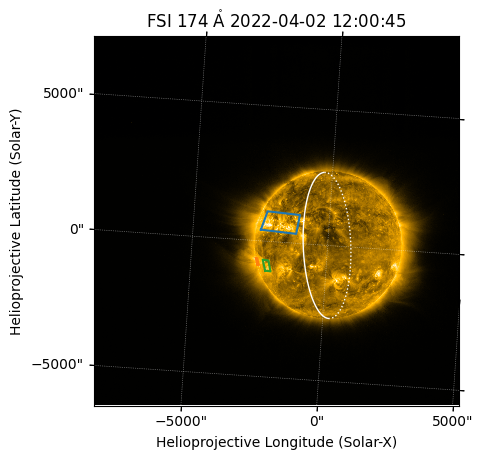

In [33]:
eui_maps[0].plot()
ax = plt.gca()
for ar in ar_areas:
    transformed_coords = ar.transform_to(eui_maps[0].coordinate_frame)
    if np.any(transformed_coords.is_visible(tolerance=1*u.km)):
        ax.plot_coord(transformed_coords[transformed_coords.is_visible(tolerance=1*u.km)])
hmi_map.draw_limb()

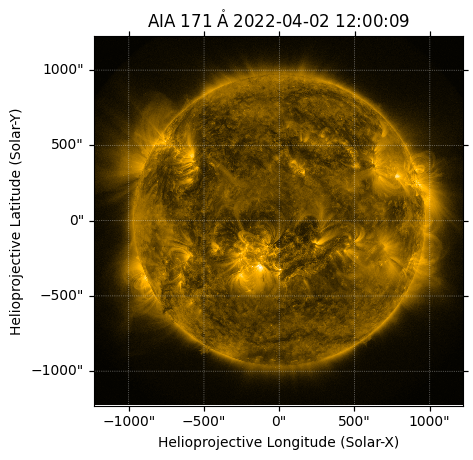

In [37]:
aia_maps[0].plot()
coord = SkyCoord(1000*u.arcsec, 

In [38]:
coord1 = SkyCoord(0*u.arcsec, 0*u.arcsec, frame=aia_maps[0].coordinate_frame)

In [39]:
coord2 = SkyCoord(900*u.arcsec, 500*u.arcsec, frame=aia_maps[0].coordinate_frame)

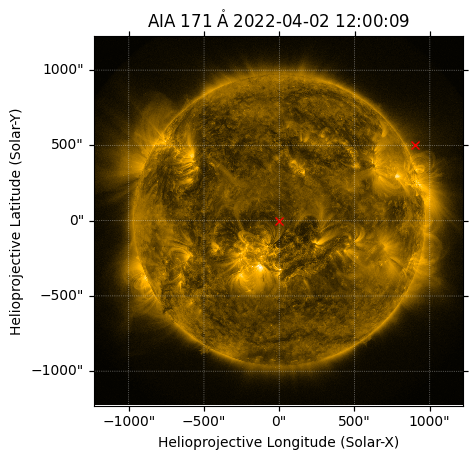

In [50]:
aia_maps[0].plot()
ax = plt.gca()
ax.plot_coord(coord1, marker='x', color='r')
ax.plot_coord(coord2, marker='x', color='r')

In [71]:
coord1_eui = coord1.transform_to(eui_maps[0].coordinate_frame)

In [76]:
coord1.transform_to(aia_maps[1].coordinate_frame)

<SkyCoord (Helioprojective: obstime=2022-04-02T12:10:10.350, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2022-04-02T12:10:10.350, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (0.01293988, -6.46631452, 1.49533817e+11)>): (Tx, Ty, distance) in (arcsec, arcsec, m)
    (-0.13198543, -0.00258615, 1.48837822e+11)>

In [75]:
coord1_eui

<SkyCoord (Helioprojective: obstime=2022-04-02T12:00:50.225, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2022-04-02T12:00:50.225, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
    (108.83451644, 2.67762384, 5.32318127e+10)>): (Tx, Ty, distance) in (arcsec, arcsec, m)
    (-2525.55222771, -261.87018439, 5.34624073e+10)>

In [56]:
from sunpy.coordinates import SphericalScreen
with SphericalScreen(aia_maps[0].observer_coordinate):
    print(coord2.transform_to(eui_maps[0].coordinate_frame))

<SkyCoord (Helioprojective: obstime=2022-04-02T12:00:50.225, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2022-04-02T12:00:50.225, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
    (108.83451644, 2.67762384, 5.32318127e+10)>): (Tx, Ty, distance) in (arcsec, arcsec, m)
    (-983.645092, 1299.08950372, 5.2613492e+10)>


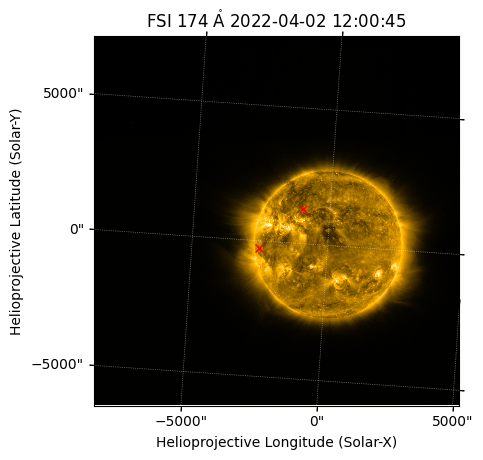

In [63]:
eui_maps[0].plot()
ax = plt.gca()
ax.plot_coord(coord1, marker='x', color='r')
with SphericalScreen(aia_maps[0].observer_coordinate):
    ax.plot_coord(coord2, marker='x', color='r')

## Bonus: overplot a PFSS extrapolation on the AIA image

To finish off, let's place this AIA image into a global magnetic context. We compute a Potential Field Source Surface (PFSS) extrapolation from an HMI synoptic magnetogram with [`sunkit-magex`](https://docs.sunpy.org/projects/sunkit-magex/en/stable/index.html) and overplot the resulting field lines on the AIA 171 Å image.

**A note on PFSS assumptions.** PFSS solves for a current-free ($\nabla \times \mathbf{B} = 0$) potential field between $1\,R_\odot$ and a *source surface* at $r = R_{ss}$ (typically $2.5\,R_\odot$), where the field is forced to be radial. This is a good approximation for the global, large-scale corona but it ignores electric currents (so it under-represents the structure inside active region cores) and it is steady-state (no time evolution). The synoptic input is also not an instantaneous snapshot, each Carrington longitude is filled in as it crosses central meridian. With those caveats in mind, PFSS gives an excellent picture of the global open vs closed field topology.

In [77]:
import sunkit_magex.pfss
import sunkit_magex.pfss.tracing as tracing
from sunpy.coordinates import HeliographicCarrington
from sunpy.coordinates.sun import carrington_rotation_number

We pick one of the AIA maps near the flare peak as the background image:

In [78]:
aia_map = aia_maps[0]
aia_map.date

<Time object: scale='utc' format='isot' value=2022-04-02T12:00:09.350>

### Download the HMI synoptic magnetogram from JSOC

We use the *polar-filled* synoptic series `hmi.synoptic_mr_polfil_720s`, HMI does not directly observe the poles, and the polar-filled product is the standard input for PFSS. We translate the AIA observation time into a Carrington rotation number and fetch the corresponding map.

JSOC requires a registered notify email. Either set the `jsoc_email` environment variable or edit the string below to your registered address.

In [79]:
crot = int(np.ceil(carrington_rotation_number(aia_map.date)))
print(f'Carrington rotation containing {aia_map.date.iso}: CR{crot}')

Carrington rotation containing 2022-04-02 12:00:09.350: CR2256


In [99]:
jsoc_email = "your_email@email.com"

result = Fido.search(
    a.jsoc.Series('hmi.synoptic_mr_polfil_720s'),
    a.jsoc.PrimeKey('CAR_ROT', crot),
    a.jsoc.Notify(jsoc_email),
)
files = Fido.fetch(result, path="./data/")
hmi_synop = sunpy.map.Map(files[0])
hmi_synop

### Compute the PFSS solution

The native synoptic map is 1440×3600, much higher resolution than the global PFSS solver needs (the potential extrapolation smooths small-scale photospheric structure exponentially with height anyway). We resample to 180×360 first to keep the solve fast.

- `nrho` : number of radial grid points between $1\,R_\odot$ and the source surface.
- `rss` : source-surface radius in $R_\odot$ (2.5 is the canonical choice).

In [85]:
nrho = 35
rss = 2.5

hmi_synop_lr = hmi_synop.resample([360, 180] * u.pix)
pfss_in = sunkit_magex.pfss.Input(hmi_synop_lr, nrho, rss)
pfss_out = sunkit_magex.pfss.pfss(pfss_in)

### Seed field lines covering the whole Sun

We place seed footpoints on the photosphere ($r = 1\,R_\odot$) on a grid that is uniform in Carrington longitude and in latitutde, Latitudes are clipped to ±89° to dodge the polar singularity.

Carrington longitude is Sun-fixed, so a `(lon, lat, r)` triple labels the same physical point at any obstime: building the seed frame from the AIA map's observer is internally consistent with the synoptic-map obstime carried by `pfss_out`.

In [89]:
n = 30
phi = np.linspace(0, 360, n, endpoint=False) * u.deg
lat_max = np.sin(np.radians(89))
theta = np.linspace(-89, 89, n) * u.deg   
phi_grid, theta_grid = np.meshgrid(phi, theta)

seeds = SkyCoord(
    phi_grid.ravel(), theta_grid.ravel(),
    radius=1.0 * u.R_sun,
    frame=HeliographicCarrington(obstime=aia_map.date,
                                  observer=aia_map.observer_coordinate),
)
print(f'{seeds.size} seed footpoints')

900 seed footpoints


### Trace the field lines

In [90]:
tracer = tracing.PerformanceTracer(max_steps=20000, step_size=2)
flines = tracer.trace(seeds, pfss_out)
print(f'Traced {len(flines)} field lines')

Traced 900 field lines


/Users/laurahayes/miniforge3/envs/espd-sunpy-2026/lib/python3.12/site-packages/sunkit_magex/pfss/tracing.py:176: UserWarning: At least one field line ran out of steps during tracing.
You should probably increase max_steps (currently set to 20000) and try again.
  warnings.warn(


### Overplot on the AIA 171 Å image

Open field lines are coloured by photospheric polarity (red = positive $B_r$, blue = negative $B_r$); closed field lines are drawn in white.

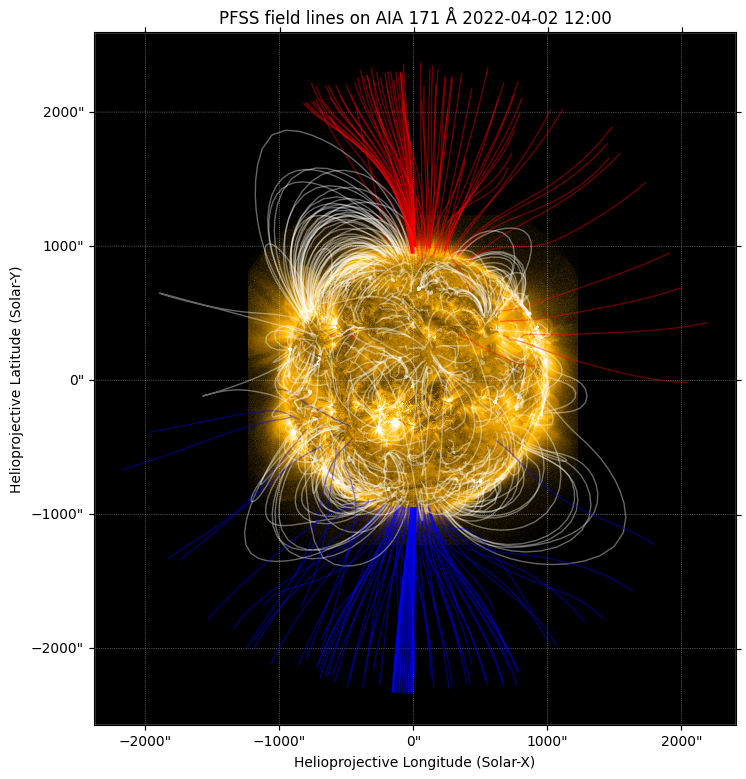

In [97]:
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(projection=aia_map)
cmap = plt.get_cmap(aia_map.plot_settings['cmap'])
aia_map.plot(axes=ax, clip_interval=(1, 99.9) * u.percent, cmap=cmap)
ax.set_facecolor(cmap(0))

for fline in flines:
    coords = fline.coords
    if coords.size < 2:
        continue
    if fline.polarity > 0:
        color = 'red'
    elif fline.polarity < 0:
        color = 'blue'
    else:
        color = 'white'
    ax.plot_coord(coords, color=color, alpha=0.4, linewidth=1)

ax.set_title(f'PFSS field lines on AIA 171 Å {aia_map.date.strftime("%Y-%m-%d %H:%M")}')
plt.show()